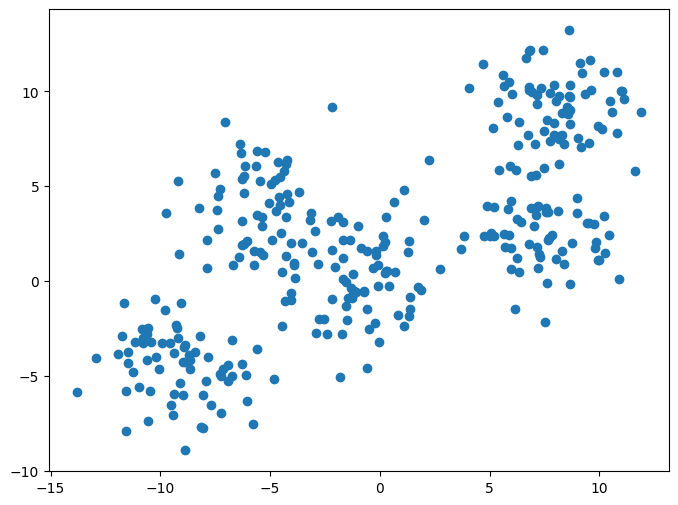

In [66]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(234)
x, _ = make_blobs(n_samples=330, centers=5, cluster_std=1.84)
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1])
plt.show()

In [67]:
def initiate_centroids(k, dset):
    centroids = dset.sample(k)
    return centroids

In [68]:
def mahalanobis_distance(x, mu, inv_cov):
    diff = x - mu
    dist_sq = np.dot(np.dot(diff, inv_cov), diff.T)
    return np.sqrt(dist_sq)

In [ ]:
def centroid_assignation(dset, centroids, inv_cov):
    k = centroids.shape[0]
    n = dset.shape[0]
    assignation = []
    assign_errors = []

    for obs in range(n):
        #Estimate error
        all_errors = np.array([])

        for centroid in range(k):
            err = mahalanobis_distance(dset.iloc[obs, :].values,
                                        centroids.iloc[centroid, :].values,
                                        inv_cov)
            all_errors = np.append(all_errors, err)
            
        all_errors = np.array(all_errors)
        nearest_centroid = np.argmin(all_errors)
        nearest_centroid_error = all_errors[nearest_centroid]
        
        assignation.append(nearest_centroid)
        assign_errors.append(nearest_centroid_error)
    return assignation, assign_errors

In [75]:
def Mahalanobis_KMeans(dset, k, tol=1e-4):
    cov_matrix = np.cov(dset.values, rowvar=False)
    inv_cov = np.linalg.pinv(cov_matrix)

    working_dset = dset.copy()
    err = []
    goahead = True
    j = 0

    centroids = initiate_centroids(k , dset)

    while(goahead):
        data_to_assign = working_dset.drop(columns=['centroid'], errors='ignore')
        
        working_dset['centroid'], j_err = centroid_assignation(data_to_assign, centroids, inv_cov)
        err.append(sum(j_err))

        centroids = working_dset.groupby('centroid').agg('mean').reset_index(drop = True)

        if j > 0:
            if err[j - 1] - err[j] <= tol:
                goahead = False
        j += 1

    data_to_assign = working_dset.drop(columns=['centroid'], errors='ignore')
        
    working_dset['centroid'], j_err = centroid_assignation(data_to_assign, centroids, inv_cov)
    
    centroids = working_dset.groupby('centroid').agg('mean').reset_index(drop = True)
    return working_dset['centroid'], j_err, centroids

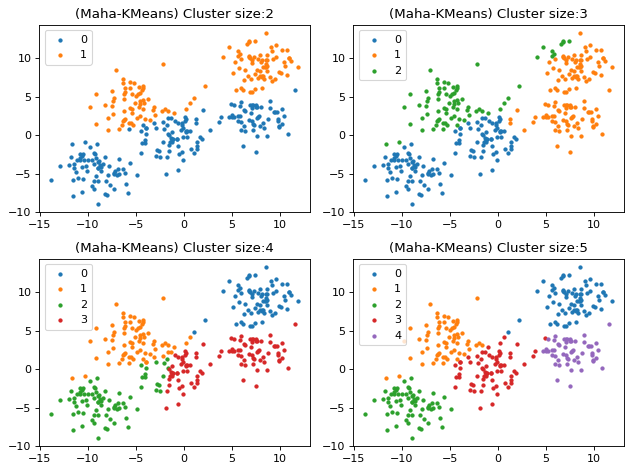

In [76]:
f = plt.figure(figsize=(8, 6), dpi=80)

for i in range(2, 6):
    pred, _, _ = Mahalanobis_KMeans(pd.DataFrame({'x':x[:,0], 'y':x[:, 1]}), i)
    df = pd.DataFrame({'x':x[:,0], 'y':x[:, 1], 'label':pred})
    groups = df.groupby('label')
    f.add_subplot(2, 2, i - 1)
    for name, group in groups:
        plt.scatter(group.x, group.y, label=name, s=8)
        plt.title("(Maha-KMeans) Cluster size:" + str(i))
        plt.legend()

plt.tight_layout()
plt.show()